# Business Objective
This analysis focuses on identifying meaningful client segments and designing targeted acquisition and retention strategies for a mutual fund advisory. The goal is to understand differences in investment behavior across customer groups and support data-driven business decision-making.


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
client = pd.read_excel("/content/Wroking sheet.xlsx", sheet_name="Sheet1")

In [ ]:
client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Client Name         266 non-null    object 
 1   Monthly income      266 non-null    object 
 2   Gender              266 non-null    object 
 3   Earning individual  266 non-null    object 
 4   Responsibility      266 non-null    object 
 5   Mode of income      266 non-null    object 
 6   Network degree      266 non-null    object 
 7   Marriage status     266 non-null    object 
 8   Risk apetite        266 non-null    object 
 9   Location            266 non-null    object 
 10  Age                 266 non-null    float64
 11  SIP                 266 non-null    int64  
 12  AUM                 266 non-null    float64
 13  Redemption amount   266 non-null    float64
 14  Redemption count    266 non-null    int64  
 15  Months              266 non-null    float64
dtypes: float

#Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Define ordinal categories in increasing order
income_categories = [['0-49999', '50000-199999', '200000-499999', '500000 and above']]
risk_categories = [['Conservative', 'Moderate', 'Aggresive']]
network_categories = [['3rd', '2nd', '1st']]

# Define column groups
ordinal_features = ['Monthly income', 'Risk apetite', 'Network degree']
ordinal_categories = income_categories + risk_categories + network_categories

nominal_features = ['Gender', 'Mode of income', 'Marriage status',
                    'Responsibility', 'Earning individual', 'Location']

# Create transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
        ('nom', OneHotEncoder(drop='first'), nominal_features)
    ],
    remainder='passthrough'  # Keep numeric columns as they are
)

# Apply transformation
client_processed = preprocessor.fit_transform(client)

# Get feature names
nominal_encoded_names = preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_features)
all_feature_names = ordinal_features + list(nominal_encoded_names) + [col for col in client.columns if col not in ordinal_features + nominal_features]

# Final DataFrame
df_processed = pd.DataFrame(client_processed, columns=all_feature_names)

df_processed.head()


,Monthly income,Risk apetite,Network degree,Gender_M,Mode of income_Salaried,Marriage status_Single,Responsibility_Yes,Earning individual_Self,Location_other,Client Name,Age,SIP,AUM,Redemption amount,Redemption count,Months
0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,AARYA VIJAY BALPANDE,22.0,10000,81488.64,0.0,0,11.0
1,2.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,AASTHA VIJAY BALPANDE,26.0,10000,51882.34,0.0,0,4.0
2,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,ABDUSSALAM CHALUKUNNAN,54.0,2500,37673.44,0.0,0,16.0
3,1.0,1.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,ABHINANDAN AJAY JEJANI,29.0,12000,1074645.39,0.0,0,71.0
4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,ADITYA GIRISH GORLE,22.0,4000,237891.78,0.0,0,34.0


In [ ]:
# First assign default Monthly AUM value (when Months == 0)
df_processed['Monthly AUM'] = df_processed['AUM'] + df_processed['Redemption amount']

# Now safely assign the division result only to rows where Months > 0
mask = df_processed['Months'] > 0
df_processed.loc[mask, 'Monthly AUM'] = (
    (df_processed.loc[mask, 'AUM'] + df_processed.loc[mask, 'Redemption amount']) / df_processed.loc[mask, 'Months']
)

df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Monthly income           266 non-null    object
 1   Risk apetite             266 non-null    object
 2   Network degree           266 non-null    object
 3   Gender_M                 266 non-null    object
 4   Mode of income_Salaried  266 non-null    object
 5   Marriage status_Single   266 non-null    object
 6   Responsibility_Yes       266 non-null    object
 7   Earning individual_Self  266 non-null    object
 8   Location_other           266 non-null    object
 9   Client Name              266 non-null    object
 10  Age                      266 non-null    object
 11  SIP                      266 non-null    object
 12  AUM                      266 non-null    object
 13  Redemption amount        266 non-null    object
 14  Redemption count         266 non-null    o

In [ ]:
# Ensure that one-hot encoded columns are numeric
for col in df_processed.columns:
    if df_processed[col].dtype == 'object':
        try:
            df_processed[col] = pd.to_numeric(df_processed[col])
        except ValueError:
            continue  # skip columns that are truly text

In [ ]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Monthly income           266 non-null    float64
 1   Risk apetite             266 non-null    float64
 2   Network degree           266 non-null    float64
 3   Gender_M                 266 non-null    float64
 4   Mode of income_Salaried  266 non-null    float64
 5   Marriage status_Single   266 non-null    float64
 6   Responsibility_Yes       266 non-null    float64
 7   Earning individual_Self  266 non-null    float64
 8   Location_other           266 non-null    float64
 9   Client Name              266 non-null    object 
 10  Age                      266 non-null    float64
 11  SIP                      266 non-null    int64  
 12  AUM                      266 non-null    float64
 13  Redemption amount        266 non-null    float64
 14  Redemption count         2

In [ ]:
df_model = df_processed.drop(columns=['Client Name'])

###Standard Scale

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#Modelling

###Regression

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_model.drop(columns=['Monthly AUM'])
y = df_model['Monthly AUM']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize ShuffleSplit cross-validator
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# To store metrics
r2_scores = []
rmse_scores = []
mae_scores = []

# Loop through splits
for train_idx, test_idx in cv.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train model
    model1 = LinearRegression()
    model1.fit(X_train, y_train)

    # Predict
    y_pred = model1.predict(X_test)

    # Evaluate
    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae_scores.append(mean_absolute_error(y_test, y_pred))

# ✅ Print average results
print("Average R² Score:", np.mean(r2_scores))
print("Average RMSE:", np.mean(rmse_scores))
print("Average MAE:", np.mean(mae_scores))


Average R² Score: 0.8308449994312594
Average RMSE: 4440.387946834022
Average MAE: 3061.0236770068004


In [ ]:
# Convert scaled array back to DataFrame with original column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Get model coefficients
coef = model1.coef_
feature_names = X_scaled_df.columns

# Create DataFrame for coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
coef_df['abs_coef'] = coef_df['Coefficient'].abs()

# Sort and display
coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(coef_df[['Feature', 'Coefficient']])

                    Feature  Coefficient
11                      AUM  8946.567062
14                   Months -3550.298266
12        Redemption amount  3446.501717
10                      SIP  2220.680372
7   Earning individual_Self   807.055260
2            Network degree  -661.205327
5    Marriage status_Single  -660.939608
6        Responsibility_Yes  -561.078648
8            Location_other  -545.095318
1              Risk apetite  -472.211833
3                  Gender_M  -325.099495
0            Monthly income   309.917978
9                       Age  -214.118130
13         Redemption count   212.451986
4   Mode of income_Salaried   -32.061038


In [ ]:
# Drop outcome-dependent features
columns_to_drop = ['AUM', 'Redemption amount', 'Redemption count', 'Months', 'Client Name', 'Location_other']
df_profile = df_processed.drop(columns=columns_to_drop)

# Separate features and target
X = df_profile.drop(columns=['Monthly AUM'])
y = df_profile['Monthly AUM']

# Scale the client profile features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ShuffleSplit cross-validation
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
r2_scores = []
rmse_scores = []
mae_scores = []

model = LinearRegression()

for train_idx, test_idx in cv.split(X_scaled):
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae_scores.append(mean_absolute_error(y_test, y_pred))

print(f"Average R² Score: {np.mean(r2_scores)}")
print(f"Average RMSE: {np.mean(rmse_scores)}")
print(f"Average MAE: {np.mean(mae_scores)}")

Average R² Score: 0.3128056996015857
Average RMSE: 9524.94270597571
Average MAE: 6085.733747287167


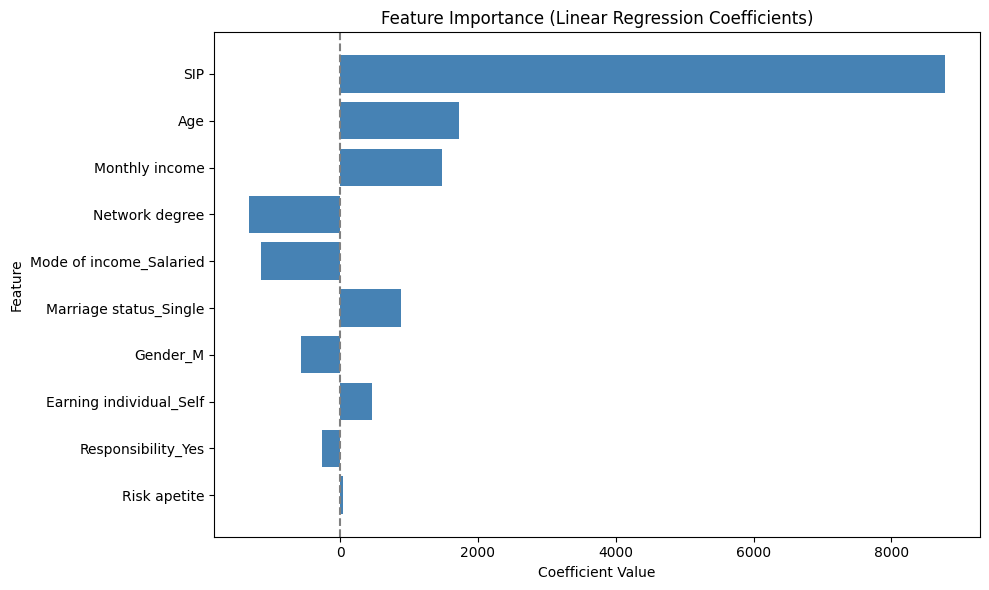

In [ ]:
import matplotlib.pyplot as plt

# Extract feature names from the scaled DataFrame
feature_names = X_scaled.columns

# Get the coefficients from the trained linear regression model
coefficients = model.coef_

# Create a DataFrame to store feature names and their coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Add a column for absolute coefficient values (importance)
importance_df['Importance'] = importance_df['Coefficient'].abs()

# Sort by importance for better visualization
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color='steelblue')
plt.axvline(x=0, color='gray', linestyle='--')
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
importance_df

,Feature,Coefficient,Importance
6,Responsibility_Yes,-670.277818,670.277818
1,Risk apetite,777.104377,777.104377
8,Age,1022.036875,1022.036875
7,Earning individual_Self,1054.008403,1054.008403
3,Gender_M,-1589.376724,1589.376724
2,Network degree,-1775.285792,1775.285792
4,Mode of income_Salaried,-1823.687200,1823.687200
5,Marriage status_Single,2218.579329,2218.579329
0,Monthly income,4574.511645,4574.511645


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Drop outcome-dependent features
columns_to_drop = ['AUM', 'Redemption amount', 'Redemption count', 'Months', 'Client Name', 'Location_other', 'Age']
df_profile = df_processed.drop(columns=columns_to_drop)

# Separate features and target
X = df_profile.drop(columns=['Monthly AUM'])
y = df_profile['Monthly AUM']

# Scale the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Initialize model and cross-validation
model2 = RandomForestRegressor(random_state=42)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

r2_scores = []
rmse_scores = []
mae_scores = []

# Train and evaluate
for train_idx, test_idx in cv.split(X_scaled):
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model2.fit(X_train, y_train)
    y_pred = model2.predict(X_test)

    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae_scores.append(mean_absolute_error(y_test, y_pred))

# Output average scores
print(f"Average R² Score: {np.mean(r2_scores)}")
print(f"Average RMSE: {np.mean(rmse_scores)}")
print(f"Average MAE: {np.mean(mae_scores)}")

# Feature Importances
importances = model2.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
importance_df


Average R² Score: 0.19394447931173336
Average RMSE: 10273.59239612691
Average MAE: 6586.810896765346

Feature Importances:


,Feature,Importance
8,SIP,0.724046
2,Network degree,0.072584
1,Risk apetite,0.046873
3,Gender_M,0.042855
0,Monthly income,0.028094
4,Mode of income_Salaried,0.027829
6,Responsibility_Yes,0.025820
5,Marriage status_Single,0.021065
7,Earning individual_Self,0.010834


###Clustering based on profile features

In [ ]:
# Features to drop (these are outcome-dependent or identifiers)
columns_to_drop = ['SIP', 'AUM', 'Redemption amount', 'Redemption count', 'Months', 'Monthly AUM', 'Client Name', 'Location_other']

# Create a new DataFrame for clustering
df_cluster = df_processed.drop(columns=columns_to_drop)

In [ ]:
X_scaled = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns)

In [ ]:
X_scaled.head()

,Monthly income,Risk apetite,Network degree,Gender_M,Mode of income_Salaried,Marriage status_Single,Responsibility_Yes,Earning individual_Self,Age
0,0.833816,-0.536824,-0.599635,-1.181692,1.298795,2.186918,-1.833209,0.439119,-1.557897
1,2.682108,-0.536824,-0.599635,-1.181692,1.298795,2.186918,-1.833209,0.439119,-1.239057
2,-1.014476,-0.536824,-0.599635,0.846244,-0.769944,-0.457265,0.545491,0.439119,0.992822
3,0.833816,-0.536824,0.850392,0.846244,-0.769944,-0.457265,0.545491,0.439119,-0.999927
4,-1.014476,-0.536824,-2.049663,0.846244,-0.769944,2.186918,-1.833209,-2.277289,-1.557897


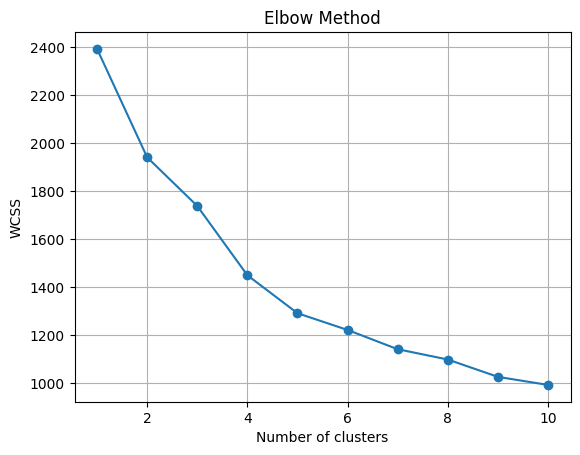

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Number of clients in each cluster:
Cluster
3    110
1     65
0     47
2     44
Name: count, dtype: int64


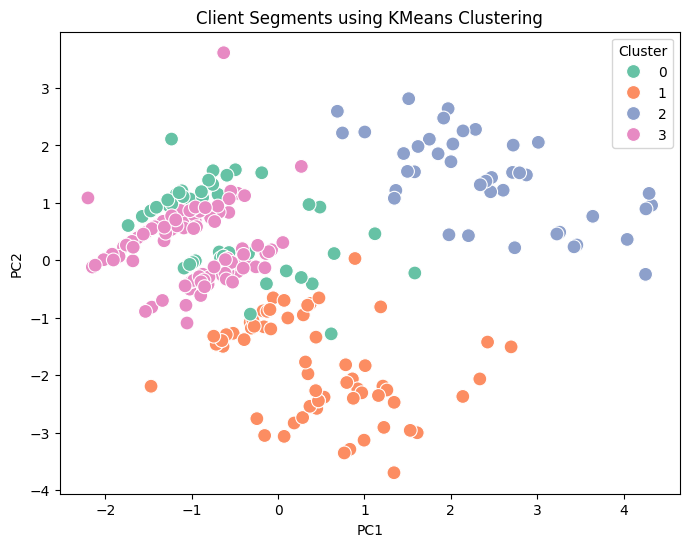


Cluster-wise Client Profile Summary:


,Monthly income,Risk apetite,Network degree,Gender_M,Mode of income_Salaried,Marriage status_Single,Responsibility_Yes,Earning individual_Self,Age
Cluster,,,,,,,,,
0,0.91,2.00,1.45,0.60,0.30,0.00,0.83,1.00,43.57
1,0.08,1.06,1.48,0.02,0.40,0.00,0.68,0.48,47.03
2,0.36,1.34,1.14,0.75,0.41,1.00,0.27,0.80,24.39
3,0.75,0.99,1.47,0.85,0.37,0.02,1.00,1.00,44.30


In [ ]:
import seaborn as sns

# Apply KMeans with optimal number of clusters (we'll use 4 based on elbow method)
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original unscaled df_processed for interpretation
df_processed['Cluster'] = cluster_labels

# Cluster count
print("Number of clients in each cluster:")
print(df_processed['Cluster'].value_counts())

# -------------------------------
# Optional: PCA for 2D visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)
df_vis = pd.DataFrame(reduced, columns=['PC1', 'PC2'])
df_vis['Cluster'] = cluster_labels

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=100)
plt.title('Client Segments using KMeans Clustering')
plt.show()

# -------------------------------
# Cluster Profiling: Numerical Summary
print("\nCluster-wise Client Profile Summary:")
profile_features = df_cluster.columns.tolist()
cluster_profile = df_processed.groupby('Cluster')[profile_features].mean().round(2)
display(cluster_profile)

In [ ]:
investment_columns = ['AUM', 'Monthly AUM', 'SIP', 'Redemption amount', 'Redemption count']
df_processed.groupby('Cluster')[investment_columns].mean().round(2)

,AUM,Monthly AUM,SIP,Redemption amount,Redemption count
Cluster,,,,,
0,595833.06,14055.19,9255.32,109086.71,2.79
1,192116.12,7062.32,3415.38,97951.38,3.97
2,333163.92,11553.30,9022.73,41227.43,1.07
3,344269.94,9723.76,5459.09,127127.39,1.90


<ipython-input-23-05d91216d0c3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Cluster', y=col, palette='Set2')


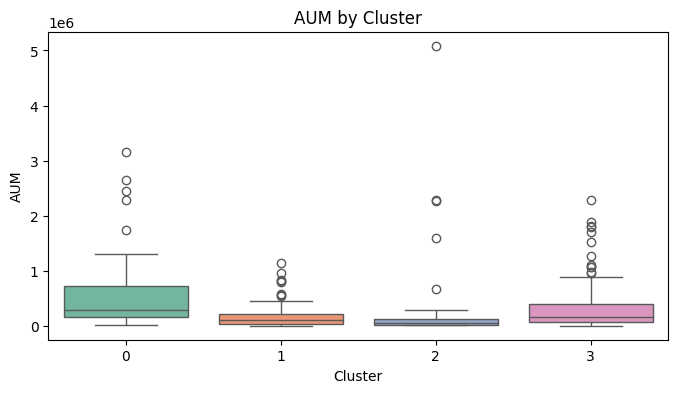

<ipython-input-23-05d91216d0c3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Cluster', y=col, palette='Set2')


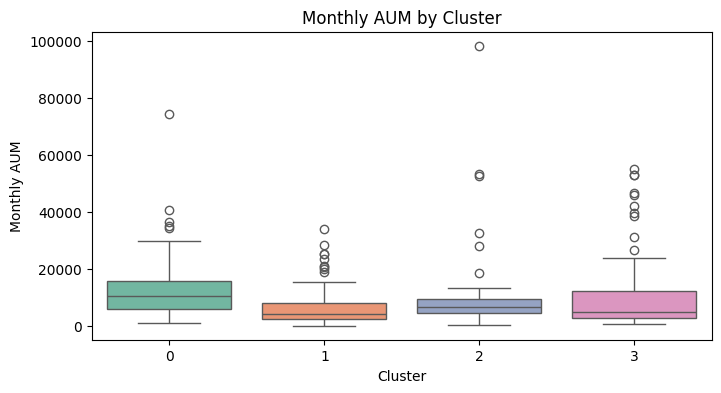

<ipython-input-23-05d91216d0c3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Cluster', y=col, palette='Set2')


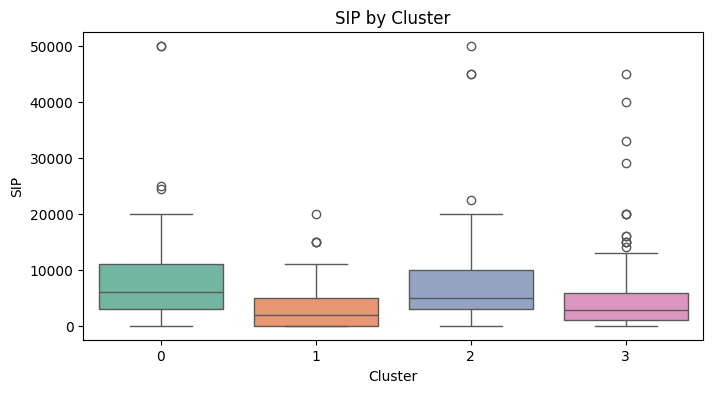

In [ ]:
for col in ['AUM', 'Monthly AUM', 'SIP']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_processed, x='Cluster', y=col, palette='Set2')
    plt.title(f'{col} by Cluster')
    plt.show()

<ipython-input-24-0a662e2e7717>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_processed, x='Cluster', y=col, palette='pastel', inner='box')


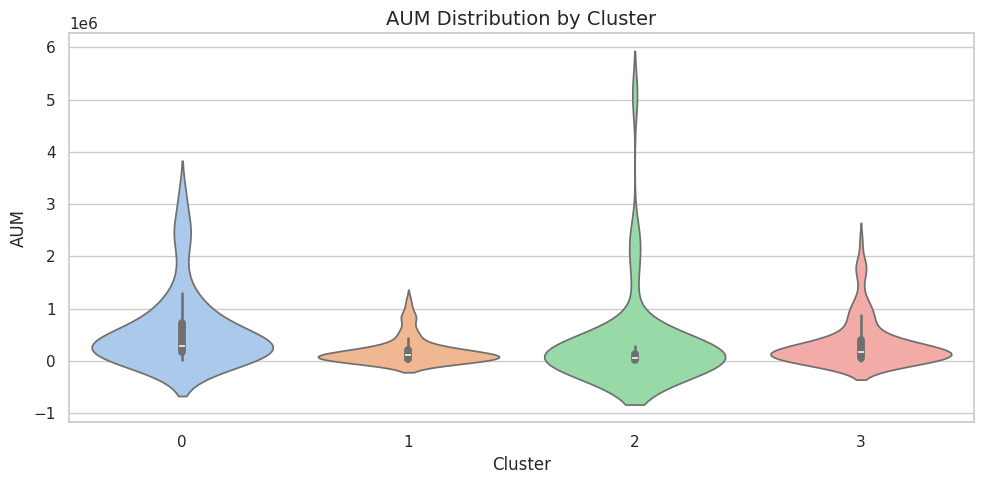

<ipython-input-24-0a662e2e7717>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_processed, x='Cluster', y=col, palette='pastel', inner='box')


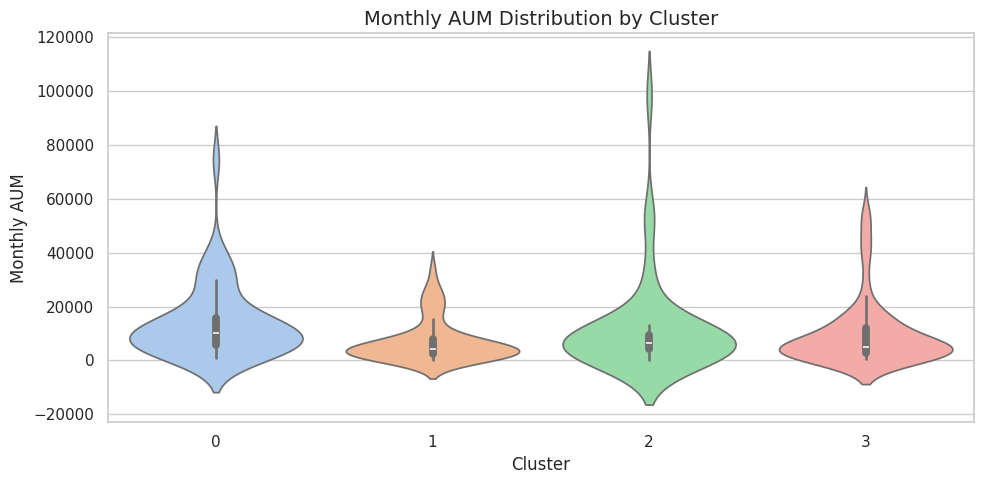

<ipython-input-24-0a662e2e7717>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_processed, x='Cluster', y=col, palette='pastel', inner='box')


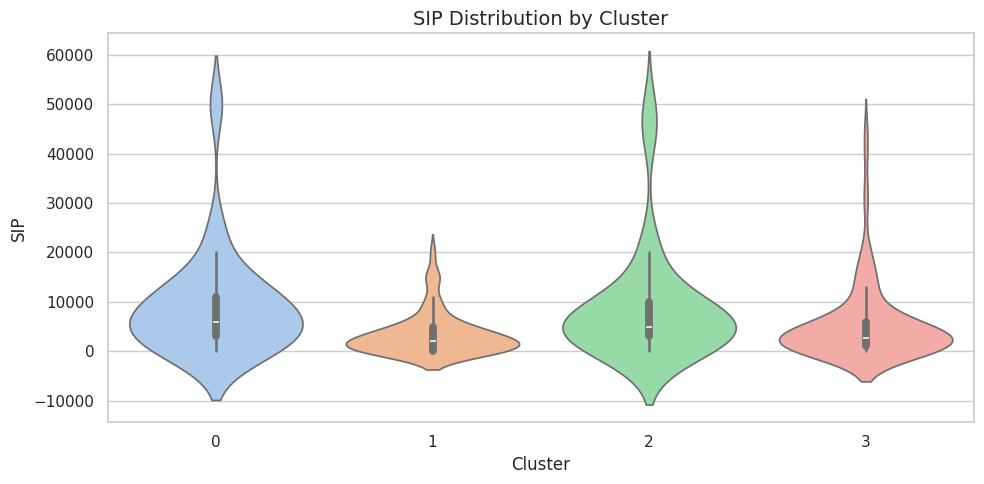

<ipython-input-24-0a662e2e7717>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_processed, x='Cluster', y=col, palette='pastel', inner='box')


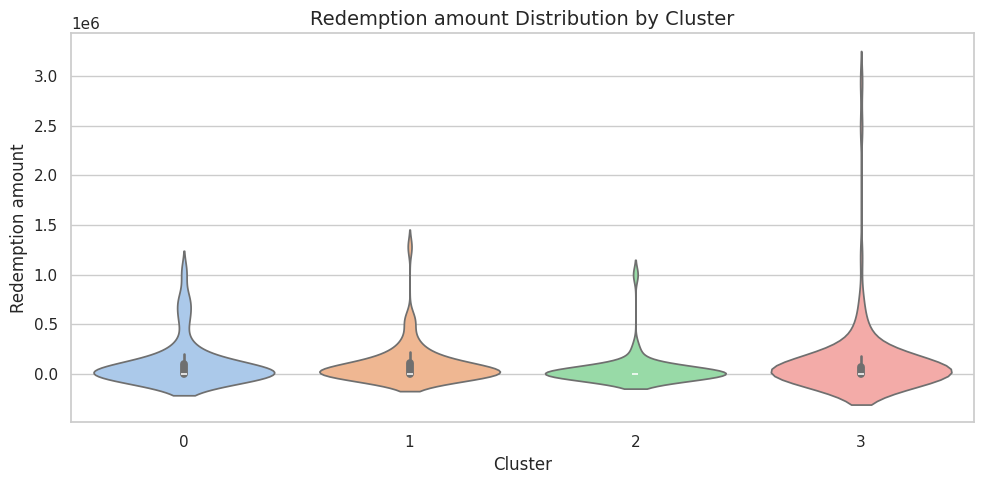

<ipython-input-24-0a662e2e7717>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_processed, x='Cluster', y=col, palette='pastel', inner='box')


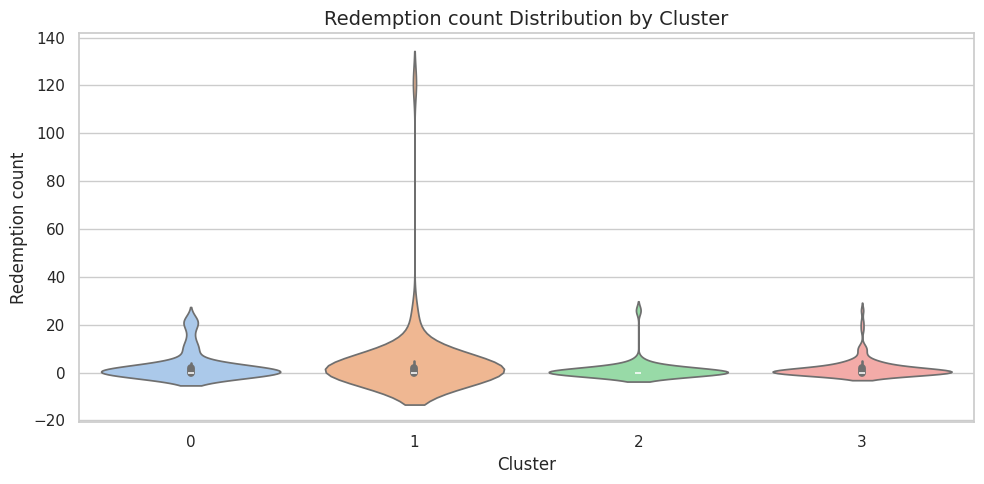

In [ ]:
# Set style
sns.set(style="whitegrid")

# Violin plot for selected columns
investment_columns = ['AUM', 'Monthly AUM', 'SIP', 'Redemption amount', 'Redemption count']

for col in investment_columns:
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df_processed, x='Cluster', y=col, palette='pastel', inner='box')
    plt.title(f'{col} Distribution by Cluster', fontsize=14)
    plt.xlabel('Cluster')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()